In [21]:
!pip install biopython --upgrade --quiet

In [22]:
# ============================================================
# Cell 1: Install & Imports
# ============================================================

!pip install requests biopython pandas tqdm openpyxl \
             wordcloud matplotlib seaborn Bio -q

import requests
import sqlite3
import json
import re
import time
import logging
import pandas as pd
from datetime       import datetime, timedelta
from tqdm import tqdm
from pathlib        import Path
import warnings
warnings.filterwarnings("ignore")

# Biopython Entrez — official PubMed API interface
from Bio import Entrez
from Bio import Medline

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s"
)
logger = logging.getLogger(__name__)
print("✅ Imports done")

✅ Imports done


In [23]:
# ============================================================
# Cell 2: Debug — Confirm PubMed API is reachable
# ============================================================

import requests

def debug_pubmed():
    print("=" * 65)
    print("  PUBMED API CONNECTIVITY CHECK")
    print("=" * 65)

    tests = [
        # E-utilities base
        ("ESearch (basic)",
         "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
         {"db":"pubmed","term":"neoantigen","retmax":1,"retmode":"json"}),

        # EFetch single article
        ("EFetch PMID 33508408",
         "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi",
         {"db":"pubmed","id":"33508408","rettype":"medline","retmode":"text"}),

        # EInfo — DB metadata
        ("EInfo",
         "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/einfo.fcgi",
         {"db":"pubmed","retmode":"json"}),

        # EGQuery — global counts
        ("EGQuery count",
         "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/egquery.fcgi",
         {"term":"neoantigen","retmode":"json"}),
    ]

    SESSION = requests.Session()
    SESSION.headers["User-Agent"] = "NeoantigenScraper/1.0 (research use)"

    for name, url, params in tests:
        print(f"\n🔗 {name}")
        print(f"   URL: {url}")
        try:
            r = SESSION.get(url, params=params, timeout=20)
            print(f"   Status : {r.status_code}")
            print(f"   Chars  : {len(r.text):,}")
            print(f"   Preview: {r.text[:200].strip()}")
            if r.status_code == 200:
                print("   ✅ OK")
            else:
                print("   ❌ FAILED")
        except Exception as e:
            print(f"   ❌ ERROR: {e}")
        time.sleep(0.5)

    print("\n" + "=" * 65)
    print("  DEBUG COMPLETE")
    print("=" * 65)

debug_pubmed()


# ============================================================
# Cell 3: Configuration
# ============================================================

# ⚠️  IMPORTANT: Set your email — NCBI requires it for API use.
#     Get a free API key at: https://www.ncbi.nlm.nih.gov/account/
#     With API key: 10 requests/sec  |  Without: 3 requests/sec

ENTREZ_EMAIL   = "shaurya@nii.ac.in"          # ← CHANGE THIS
ENTREZ_API_KEY = "a51d00da9ca124b2620d92612fa8bc15f308"                         # ← OPTIONAL but recommended

# Configure Biopython Entrez
Entrez.email   = ENTREZ_EMAIL
Entrez.api_key = ENTREZ_API_KEY if ENTREZ_API_KEY else None
Entrez.tool    = "NeoantigenScraper"

CONFIG = {
    "db_path"      : "neoantigen_pubmed.db",
    "email"        : ENTREZ_EMAIL,
    "api_key"      : ENTREZ_API_KEY,

    # ── Search query ─────────────────────────────────────────
    # PubMed uses MeSH terms + free text + field tags
    # [tiab] = title or abstract
    # [MeSH] = MeSH controlled vocabulary
    # We combine broad + specific terms with OR/AND
    "search_queries": [
        # Core term — broad
        'neoantigen[tiab]',
        'neoantigens[tiab]',
        'neoepitope[tiab]',
        'neoepitopes[tiab]',

        # MeSH + synonyms
        '"tumor neoantigen"[tiab]',
        '"tumour neoantigen"[tiab]',
        '"cancer neoantigen"[tiab]',
        '"personalized neoantigen"[tiab]',
        '"shared neoantigen"[tiab]',
        '"public neoantigen"[tiab]',
        '"private neoantigen"[tiab]',

        # Related concepts
        '"mutation-derived antigen"[tiab]',
        '"somatic mutation"[tiab] AND "T cell"[tiab] AND "tumor"[tiab]',
        '"mutant peptide"[tiab] AND "immunotherapy"[tiab]',
        '"neoantigen vaccine"[tiab]',
        '"personalized cancer vaccine"[tiab]',
        '"tumor mutational burden"[tiab]',
        '"neoantigen prediction"[tiab]',
        '"neoantigen identification"[tiab]',
        '"HLA"[tiab] AND "neoantigen"[tiab]',
        '"MHC"[tiab] AND "neoantigen"[tiab]',
        '"neoantigen-specific"[tiab]',
        '"adoptive cell therapy"[tiab] AND "neoantigen"[tiab]',
        '"tumor infiltrating lymphocyte"[tiab] AND "neoantigen"[tiab]',
        '"checkpoint"[tiab] AND "neoantigen"[tiab]',
        '"whole exome sequencing"[tiab] AND "neoantigen"[tiab]',
        '"RNA sequencing"[tiab] AND "neoantigen"[tiab]',
        '"neoantigen landscape"[tiab]',
        '"neoantigen load"[tiab]',
        '"neoantigen burden"[tiab]',
        '"frameshift neoantigen"[tiab]',
        '"fusion neoantigen"[tiab]',
    ],

    # ── Master combined query (most efficient — one API call) ──
    # Runs ALL terms at once; individual queries above used
    # only for breakdown statistics.
    "master_query": (
        '(neoantigen[tiab] OR neoantigens[tiab] OR '
        'neoepitope[tiab] OR neoepitopes[tiab] OR '
        '"tumor neoantigen"[tiab] OR "cancer neoantigen"[tiab] OR '
        '"neoantigen vaccine"[tiab] OR "neoantigen prediction"[tiab] OR '
        '"personalized cancer vaccine"[tiab] OR '
        '"neoantigen-specific"[tiab] OR "neoantigen load"[tiab] OR '
        '"neoantigen burden"[tiab] OR "neoantigen landscape"[tiab] OR '
        '"mutation-derived antigen"[tiab] OR "mutant peptide"[tiab])'
    ),

    # ── Date range ───────────────────────────────────────────
    "date_from" : "2000/01/01",   # PubMed format: YYYY/MM/DD
    "date_to"   : datetime.today().strftime("%Y/%m/%d"),

    # ── API settings ─────────────────────────────────────────
    "batch_size"    : 500,       # records per EFetch call (max 10000)
    "request_delay" : 0.34,      # ~3 req/s without key; 0.11 with key
    "max_retries"   : 5,

    # ── Fetch full records? ───────────────────────────────────
    "fetch_abstracts" : True,    # always True for Medline format
    "fetch_mesh"      : True,    # MeSH terms from Medline record
    "fetch_references": False,   # too slow without PMC API
}

# Adjust delay if API key provided
if ENTREZ_API_KEY:
    CONFIG["request_delay"] = 0.11
    print("✅ API key set — 10 requests/sec unlocked")

print(f"✅ Config ready")
print(f"   Email      : {CONFIG['email']}")
print(f"   Date range : {CONFIG['date_from']} → {CONFIG['date_to']}")
print(f"   Queries    : {len(CONFIG['search_queries'])} individual + 1 master")
print(f"   Batch size : {CONFIG['batch_size']}")


# ============================================================
# Cell 4: Database Schema
# ============================================================

def init_db(path: str) -> sqlite3.Connection:
    conn = sqlite3.connect(path, check_same_thread=False)
    conn.executescript("""
        -- ── Main articles table ────────────────────────────
        CREATE TABLE IF NOT EXISTS articles (
            id                  INTEGER PRIMARY KEY AUTOINCREMENT,

            -- Core identifiers
            pmid                TEXT    UNIQUE NOT NULL,
            pmcid               TEXT,
            doi                 TEXT,

            -- Bibliographic
            title               TEXT,
            abstract            TEXT,
            journal             TEXT,
            journal_abbr        TEXT,
            volume              TEXT,
            issue               TEXT,
            pages               TEXT,
            pub_date            TEXT,    -- YYYY-MM-DD or YYYY-MM or YYYY
            pub_year            INTEGER,
            pub_types           TEXT,    -- JSON list
            language            TEXT,

            -- Authors (stored as JSON; detail in authors table)
            authors_json        TEXT,    -- JSON list of {name, affil}
            first_author        TEXT,
            last_author         TEXT,
            corresponding_email TEXT,

            -- MeSH / Keywords
            mesh_terms          TEXT,    -- JSON list
            keywords            TEXT,    -- JSON list (author keywords)
            chemical_names      TEXT,    -- JSON list

            -- Citation / Impact
            cited_by            INTEGER  DEFAULT 0,

            -- Full text availability
            has_pmc_fulltext    INTEGER  DEFAULT 0,
            pmc_url             TEXT,
            pubmed_url          TEXT,
            doi_url             TEXT,

            -- Grants / Funding
            grants              TEXT,    -- JSON list

            -- Our metadata
            query_matched       TEXT,    -- which query found this
            created_at          TEXT     DEFAULT CURRENT_TIMESTAMP,
            updated_at          TEXT     DEFAULT CURRENT_TIMESTAMP
        );

        -- ── Author details ──────────────────────────────────
        CREATE TABLE IF NOT EXISTS authors (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            pmid         TEXT,
            position     INTEGER,
            last_name    TEXT,
            fore_name    TEXT,
            full_name    TEXT,
            initials     TEXT,
            affiliation  TEXT,
            orcid        TEXT,
            is_first     INTEGER DEFAULT 0,
            is_last      INTEGER DEFAULT 0,
            FOREIGN KEY (pmid) REFERENCES articles(pmid)
        );

        -- ── MeSH term detail ────────────────────────────────
        CREATE TABLE IF NOT EXISTS mesh (
            id            INTEGER PRIMARY KEY AUTOINCREMENT,
            pmid          TEXT,
            descriptor    TEXT,
            qualifier     TEXT,
            is_major      INTEGER DEFAULT 0,
            FOREIGN KEY (pmid) REFERENCES articles(pmid)
        );

        -- ── Grants ──────────────────────────────────────────
        CREATE TABLE IF NOT EXISTS grants (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            pmid        TEXT,
            grant_id    TEXT,
            acronym     TEXT,
            agency      TEXT,
            country     TEXT,
            FOREIGN KEY (pmid) REFERENCES articles(pmid)
        );

        -- ── Scrape sessions ─────────────────────────────────
        CREATE TABLE IF NOT EXISTS sessions (
            id            INTEGER PRIMARY KEY AUTOINCREMENT,
            started_at    TEXT,
            finished_at   TEXT,
            query         TEXT,
            total_found   INTEGER DEFAULT 0,
            new_inserted  INTEGER DEFAULT 0,
            updated       INTEGER DEFAULT 0,
            status        TEXT
        );

        -- ── Indexes ─────────────────────────────────────────
        CREATE INDEX IF NOT EXISTS idx_pmid      ON articles(pmid);
        CREATE INDEX IF NOT EXISTS idx_doi       ON articles(doi);
        CREATE INDEX IF NOT EXISTS idx_year      ON articles(pub_year);
        CREATE INDEX IF NOT EXISTS idx_journal   ON articles(journal);
        CREATE INDEX IF NOT EXISTS idx_auth_pmid ON authors(pmid);
        CREATE INDEX IF NOT EXISTS idx_mesh_pmid ON mesh(pmid);
    """)
    conn.commit()
    print(f"✅ Database ready → {path}")
    return conn


conn = init_db(CONFIG["db_path"])

  PUBMED API CONNECTIVITY CHECK

🔗 ESearch (basic)
   URL: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi
   Status : 200
   Chars  : 820
   Preview: {"header":{"type":"esearch","version":"0.3"},"esearchresult":{"count":"162408","retmax":"1","retstart":"0","idlist":["42032761"],"translationset":[{"from":"neoantigen","to":"\"antigens, neoplasm\"[Sup
   ✅ OK

🔗 EFetch PMID 33508408
   URL: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi
   Status : 200
   Chars  : 5,282
   Preview: PMID- 33508408
OWN - NLM
STAT- MEDLINE
DCOM- 20210630
LR  - 20210630
IS  - 1872-678X (Electronic)
IS  - 0165-0270 (Linking)
VI  - 353
DP  - 2021 Apr 1
TI  - Use of common average reference and large-
   ✅ OK

🔗 EInfo
   URL: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/einfo.fcgi
   Status : 200
   Chars  : 15,170
   Preview: {"header":{"type":"einfo","version":"0.3"},"einforesult":{"dbinfo":[{"dbname":"pubmed","menuname":"PubMed","description":"PubMed bibliographic record","dbbuild":"Bu

In [24]:
# ============================================================
# Cell 5: ESearch — Get All PMIDs matching query
# ============================================================

def esearch_all(query: str, config: dict) -> list[str]:
    """
    Use ESearch + usehistory to retrieve ALL PMIDs for a query.
    Returns a list of PMID strings.
    """
    print(f"🔍 ESearch query:\n   {query[:120]}{'...' if len(query)>120 else ''}")

    # Step 1 — initial search to get total count & WebEnv
    handle = Entrez.esearch(
        db         = "pubmed",
        term       = query,
        retmax     = 0,                # just get count first
        usehistory = "y",
        mindate    = config["date_from"],
        maxdate    = config["date_to"],
        datetype   = "pdat",           # publication date
    )
    record    = Entrez.read(handle)
    handle.close()

    total     = int(record["Count"])
    web_env   = record["WebEnv"]
    query_key = record["QueryKey"]

    print(f"   Total articles found : {total:,}")

    if total == 0:
        return []

    # Step 2 — retrieve all PMIDs in batches
    all_pmids = []
    batch     = config["batch_size"]

    pbar = tqdm(total=total, desc="  Fetching PMIDs", unit=" pmids")

    for start in range(0, total, batch):
        time.sleep(config["request_delay"])
        for attempt in range(config["max_retries"]):
            try:
                handle = Entrez.esearch(
                    db         = "pubmed",
                    term       = query,
                    retstart   = start,
                    retmax     = batch,
                    usehistory = "y",
                    WebEnv     = web_env,
                    query_key  = query_key,
                    mindate    = config["date_from"],
                    maxdate    = config["date_to"],
                    datetype   = "pdat",
                )
                batch_record = Entrez.read(handle)
                handle.close()
                all_pmids.extend(batch_record["IdList"])
                pbar.update(len(batch_record["IdList"]))
                break
            except Exception as e:
                logger.warning(f"ESearch error attempt {attempt+1}: {e}")
                time.sleep(5 * (attempt + 1))

    pbar.close()
    all_pmids = list(set(all_pmids))   # deduplicate
    print(f"   Unique PMIDs fetched : {len(all_pmids):,}")
    return all_pmids


# ── Test with a small query first ────────────────────────────
print("🧪 Testing ESearch with 'neoantigen vaccine' ...")
test_pmids = esearch_all('"neoantigen vaccine"[tiab]', CONFIG)
print(f"   Got {len(test_pmids)} PMIDs")
if test_pmids:
    print(f"   Sample: {test_pmids[:5]}")

🧪 Testing ESearch with 'neoantigen vaccine' ...
🔍 ESearch query:
   "neoantigen vaccine"[tiab]
   Total articles found : 159


  Fetching PMIDs: 100%|██████████| 159/159 [00:01<00:00, 156.75 pmids/s]

   Unique PMIDs fetched : 159
   Got 159 PMIDs
   Sample: ['34010258', '38280084', '41632561', '32439700', '40067898']


In [25]:
# ============================================================
# Cell 6: Medline Parser — extract all fields from a record
# ============================================================

def safe(record: dict, key: str, default="") -> str:
    """Safely get a string field from a Medline record."""
    val = record.get(key, default)
    if isinstance(val, list):
        return "; ".join(str(v) for v in val)
    return str(val) if val else default


# def parse_pub_date(record: dict) -> tuple[str, int]:
#     """
#     Extract publication date → (date_str, year_int).
#     Tries DP (Date of Publication) first, then EDAT.
#     """
#     raw = record.get("DP", record.get("EDAT", ""))
#     year = 0
#     m = re.search(r"(\d{4})", raw)
#     if m:
#         year = int(m.group(1))

#     # Normalise to YYYY-MM-DD where possible
#     raw = raw.strip()
#     for fmt in ("%Y %b %d", "%Y %b", "%Y"):
#         try:
#             dt = datetime.strptime(raw[:len(fmt.replace('%Y','2024').replace('%b','Jan').replace('%d','01'))], fmt)
#             return dt.strftime("%Y-%m-%d"), year
#         except Exception:
#             pass
#     return raw[:10], year


def parse_pub_date(record: dict) -> tuple[str, int]:
    raw = record.get("DP", record.get("EDAT", ""))
    year = 0
    m = re.search(r"(\d{4})", raw)
    if m:
        year = int(m.group(1))

    # Clean up common Medline weirdness (e.g. "2021 Jan-Feb", "2021 Spring")
    clean_raw = re.split(r"[-/A-Za-z]+$", raw)[0].strip() # removes trailing seasons/ranges
    
    for fmt in ("%Y %b %d", "%Y %b", "%Y %m %d", "%Y"):
        try:
            # Safely parse matching formats
            dt = datetime.strptime(clean_raw, fmt)
            return dt.strftime("%Y-%m-%d"), year
        except ValueError:
            continue
            
    return raw[:10], year # Fallback


def parse_authors_medline(record: dict) -> list[dict]:
    """Parse AU + AD (affiliation) fields."""
    authors_raw = record.get("AU", [])
    affiliations = record.get("AD", [])
    fau_raw      = record.get("FAU", [])  # full author names

    authors = []
    for i, name in enumerate(authors_raw):
        parts = name.split(" ", 1)
        last  = parts[0]
        inits = parts[1] if len(parts) > 1 else ""
        # Try to get full name from FAU
        full  = fau_raw[i] if i < len(fau_raw) else name
        affil = affiliations[i] if i < len(affiliations) else ""

        authors.append({
            "position" : i + 1,
            "last_name": last,
            "fore_name": inits,
            "full_name": full,
            "initials" : inits,
            "affiliation": affil,
            "orcid"    : "",
            "is_first" : 1 if i == 0 else 0,
            "is_last"  : 1 if i == len(authors_raw) - 1 else 0,
        })
    return authors


def parse_mesh_medline(record: dict) -> list[dict]:
    """Parse MH (MeSH heading) field."""
    mh_list = record.get("MH", [])
    mesh    = []
    for mh in mh_list:
        is_major = 1 if mh.startswith("*") else 0
        mh       = mh.lstrip("*")
        if "/" in mh:
            descriptor, qualifier = mh.split("/", 1)
        else:
            descriptor, qualifier = mh, ""
        mesh.append({
            "descriptor": descriptor.strip(),
            "qualifier" : qualifier.strip(),
            "is_major"  : is_major,
        })
    return mesh


def parse_grants_medline(record: dict) -> list[dict]:
    """Parse GR (grant) field."""
    gr_list = record.get("GR", [])
    grants  = []
    for gr in gr_list:
        parts = gr.split("/")
        grants.append({
            "grant_id": parts[0].strip() if parts else gr,
            "acronym" : parts[1].strip() if len(parts) > 1 else "",
            "agency"  : parts[2].strip() if len(parts) > 2 else "",
            "country" : parts[3].strip() if len(parts) > 3 else "",
        })
    return grants


def medline_to_record(record: dict, query_matched: str = "") -> dict:
    """
    Convert one Biopython Medline record → clean dict for DB.
    """
    pmid      = safe(record, "PMID")
    pub_date, pub_year = parse_pub_date(record)
    authors   = parse_authors_medline(record)
    mesh      = parse_mesh_medline(record)
    grants_l  = parse_grants_medline(record)

    # DOI
    doi = ""
    for lid in record.get("LID", []):
        if "[doi]" in lid.lower():
            doi = lid.replace("[doi]","").replace("[DOI]","").strip()
            break
    if not doi:
        aid = safe(record, "AID")
        m   = re.search(r"10\.\d{4,}/\S+", aid)
        if m:
            doi = m.group().rstrip(".")

    # PMC
    pmcid = ""
    for pmid_type in record.get("PMC", []):
        if str(pmid_type).startswith("PMC"):
            pmcid = str(pmid_type); break
    if not pmcid:
        pmcid = safe(record, "PMC")

    # Pub types
    pub_types = [str(pt) for pt in record.get("PT", [])]

    # Chemical names
    chemicals = record.get("RN", [])
    chem_names = record.get("NM", chemicals)

    return {
        # identifiers
        "pmid"               : pmid,
        "pmcid"              : pmcid,
        "doi"                : doi,
        # bibliographic
        "title"              : safe(record, "TI"),
        "abstract"           : safe(record, "AB"),
        "journal"            : safe(record, "JT"),
        "journal_abbr"       : safe(record, "TA"),
        "volume"             : safe(record, "VI"),
        "issue"              : safe(record, "IP"),
        "pages"              : safe(record, "PG"),
        "pub_date"           : pub_date,
        "pub_year"           : pub_year,
        "pub_types"          : json.dumps(pub_types),
        "language"           : safe(record, "LA"),
        # authors
        "authors_json"       : json.dumps([a["full_name"] for a in authors]),
        "first_author"       : authors[0]["full_name"] if authors else "",
        "last_author"        : authors[-1]["full_name"] if authors else "",
        "corresponding_email": "",     # not in Medline; enriched later
        # MeSH / keywords
        "mesh_terms"         : json.dumps([m["descriptor"] for m in mesh]),
        "keywords"           : json.dumps([str(k) for k in record.get("OT", [])]),
        "chemical_names"     : json.dumps([str(c) for c in chem_names] if chem_names else []),
        # URLs
        "has_pmc_fulltext"   : 1 if pmcid else 0,
        "pmc_url"            : f"https://www.ncbi.nlm.nih.gov/pmc/articles/{pmcid}/" if pmcid else "",
        "pubmed_url"         : f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",
        "doi_url"            : f"https://doi.org/{doi}" if doi else "",
        # grants
        "grants"             : json.dumps(grants_l),
        # our metadata
        "query_matched"      : query_matched,
        "cited_by"           : 0,
        # private helpers
        "_authors"           : authors,
        "_mesh"              : mesh,
        "_grants"            : grants_l,
    }


print("✅ Medline parser ready")

✅ Medline parser ready


In [26]:
# ============================================================
# Cell 7: DB Insertion
# ============================================================

_DB_COLS = [
    "pmid","pmcid","doi","title","abstract","journal","journal_abbr",
    "volume","issue","pages","pub_date","pub_year","pub_types","language",
    "authors_json","first_author","last_author","corresponding_email",
    "mesh_terms","keywords","chemical_names","cited_by",
    "has_pmc_fulltext","pmc_url","pubmed_url","doi_url",
    "grants","query_matched",
]


def insert_article(conn: sqlite3.Connection,
                   rec: dict) -> tuple[bool, bool]:
    """
    Returns (is_new, is_updated).
    """
    row = {k: rec[k] for k in _DB_COLS}

    try:
        conn.execute(
            f"INSERT INTO articles ({','.join(_DB_COLS)}) "
            f"VALUES ({','.join(':'+c for c in _DB_COLS)})",
            row
        )
        conn.commit()

        # Authors
        for auth in rec["_authors"]:
            conn.execute("""
                INSERT INTO authors
                  (pmid, position, last_name, fore_name,
                   full_name, initials, affiliation,
                   orcid, is_first, is_last)
                VALUES (?,?,?,?,?,?,?,?,?,?)
            """, (
                rec["pmid"], auth["position"], auth["last_name"],
                auth["fore_name"], auth["full_name"], auth["initials"],
                auth["affiliation"], auth["orcid"],
                auth["is_first"], auth["is_last"],
            ))

        # MeSH
        for m in rec["_mesh"]:
            conn.execute("""
                INSERT INTO mesh (pmid, descriptor, qualifier, is_major)
                VALUES (?,?,?,?)
            """, (rec["pmid"], m["descriptor"],
                  m["qualifier"], m["is_major"]))

        # Grants
        for g in rec["_grants"]:
            conn.execute("""
                INSERT INTO grants (pmid, grant_id, acronym, agency, country)
                VALUES (?,?,?,?,?)
            """, (rec["pmid"], g["grant_id"], g["acronym"],
                  g["agency"], g["country"]))

        conn.commit()
        return True, False   # new

    except sqlite3.IntegrityError:
        # PMID exists — update if we have more info
        conn.execute("""
            UPDATE articles SET
                pmcid       = COALESCE(NULLIF(pmcid,''),  :pmcid),
                doi         = COALESCE(NULLIF(doi,''),    :doi),
                updated_at  = CURRENT_TIMESTAMP
            WHERE pmid = :pmid
        """, row)
        conn.commit()
        return False, True   # updated


def log_session(conn, query, total, new, updated, status, start):
    conn.execute("""
        INSERT INTO sessions
          (started_at, finished_at, query,
           total_found, new_inserted, updated, status)
        VALUES (?,?,?,?,?,?,?)
    """, (start, datetime.now().isoformat(),
          query[:500], total, new, updated, status))
    conn.commit()


print("✅ Insertion helpers ready")

✅ Insertion helpers ready


In [27]:
# ============================================================
# Cell 8: EFetch — Download Full Medline Records in Batches
# ============================================================

def efetch_batch(pmids: list[str],
                 start: int,
                 batch_size: int,
                 config: dict) -> list[dict]:
    """
    Fetch one batch of Medline records using EFetch.
    Returns list of raw Biopython Medline record dicts.
    """
    batch_ids = pmids[start: start + batch_size]
    if not batch_ids:
        return []

    for attempt in range(config["max_retries"]):
        try:
            handle  = Entrez.efetch(
                db      = "pubmed",
                id      = ",".join(batch_ids),
                rettype = "medline",
                retmode = "text",
            )
            records = list(Medline.parse(handle))
            handle.close()
            return records

        except Exception as e:
            wait = 5 * (attempt + 1)
            logger.warning(
                f"EFetch error (attempt {attempt+1}): {e} — "
                f"retrying in {wait}s"
            )
            time.sleep(wait)

    logger.error(f"EFetch failed after {config['max_retries']} attempts "
                 f"for batch starting at {start}")
    return []


def fetch_and_store(conn: sqlite3.Connection,
                    pmids: list[str],
                    config: dict,
                    query_label: str = "master") -> tuple[int,int,int]:
    """
    Given a list of PMIDs, fetch Medline records in batches
    and insert into DB.

    Returns (total, new, updated).
    """
    total   = len(pmids)
    new     = 0
    updated = 0
    batch   = config["batch_size"]

    pbar = tqdm(total=total,
                desc=f"  EFetch+Store [{query_label[:30]}]",
                unit=" articles")

    for start in range(0, total, batch):
        records = efetch_batch(pmids, start, batch, config)
        time.sleep(config["request_delay"])

        for raw_rec in records:
            pmid = raw_rec.get("PMID","").strip()
            if not pmid:
                continue

            rec    = medline_to_record(raw_rec, query_matched=query_label)
            is_new, is_upd = insert_article(conn, rec)
            if is_new:   new     += 1
            if is_upd:   updated += 1

        pbar.update(len(records))
        pbar.set_postfix({
            "new"    : new,
            "updated": updated,
            "pos"    : f"{min(start+batch,total)}/{total}",
        })

    pbar.close()
    return total, new, updated


print("✅ EFetch pipeline ready")

✅ EFetch pipeline ready


In [28]:
# ============================================================
# Cell 9: MASTER SCRAPE — Run the full neoantigen query
# ============================================================

print("=" * 65)
print("  🧬  NEOANTIGEN PUBMED SCRAPER")
print("=" * 65)

session_start = datetime.now().isoformat()

# ── Step 1: Get all PMIDs ────────────────────────────────────
print("\n📋 Step 1: ESearch — fetching all matching PMIDs …")
all_pmids = esearch_all(CONFIG["master_query"], CONFIG)

if not all_pmids:
    print("❌ No PMIDs found. Check your query and date range.")
else:
    print(f"\n✅ {len(all_pmids):,} unique PMIDs to process")

    # ── Step 2: Fetch & store Medline records ────────────────
    print("\n📥 Step 2: EFetch — downloading Medline records …")
    total, new, updated = fetch_and_store(
        conn, all_pmids, CONFIG, query_label="master_neoantigen"
    )

    log_session(conn,
                CONFIG["master_query"],
                total, new, updated,
                "ok", session_start)

    print(f"\n{'='*65}")
    print(f"  ✅ MASTER SCRAPE COMPLETE")
    print(f"     PMIDs searched  : {len(all_pmids):,}")
    print(f"     New articles    : {new:,}")
    print(f"     Updated         : {updated:,}")
    print(f"{'='*65}")

  🧬  NEOANTIGEN PUBMED SCRAPER

📋 Step 1: ESearch — fetching all matching PMIDs …
🔍 ESearch query:
   (neoantigen[tiab] OR neoantigens[tiab] OR neoepitope[tiab] OR neoepitopes[tiab] OR "tumor neoantigen"[tiab] OR "cancer n...
   Total articles found : 7,191


  Fetching PMIDs: 100%|██████████| 7191/7191 [00:16<00:00, 441.05 pmids/s]


   Unique PMIDs fetched : 7,191

✅ 7,191 unique PMIDs to process

📥 Step 2: EFetch — downloading Medline records …


  EFetch+Store [master_neoantigen]: 100%|██████████| 7191/7191 [09:18<00:00, 12.87 articles/s, new=6191, updated=1000, pos=7191/7191]


  ✅ MASTER SCRAPE COMPLETE
     PMIDs searched  : 7,191
     New articles    : 6,191
     Updated         : 1,000


In [29]:
# ============================================================
# Cell 10: SUPPLEMENTARY — Run each sub-query individually
#          (builds per-query breakdown stats)
# ============================================================

def run_sub_queries(conn: sqlite3.Connection, config: dict):
    """
    Run each query in config['search_queries'] individually.
    Useful for understanding which terms are most productive.
    """
    results = []

    print(f"🔍 Running {len(config['search_queries'])} sub-queries …\n")

    for query in tqdm(config["search_queries"],
                      desc="Sub-queries"):
        s_start = datetime.now().isoformat()
        try:
            pmids = esearch_all(query, config)
            if not pmids:
                results.append({
                    "query": query, "found": 0, "new": 0
                })
                continue

            # Only fetch PMIDs not already in DB
            existing = set(
                r[0] for r in conn.execute(
                    f"SELECT pmid FROM articles WHERE pmid IN "
                    f"({','.join('?'*len(pmids))})",
                    pmids
                ).fetchall()
            )
            new_pmids = [p for p in pmids if p not in existing]

            if new_pmids:
                _, new, upd = fetch_and_store(
                    conn, new_pmids, config,
                    query_label=query[:100]
                )
            else:
                new, upd = 0, 0

            log_session(conn, query, len(pmids), new, upd,
                        "ok", s_start)
            results.append({
                "query": query,
                "found": len(pmids),
                "new"  : new,
            })

            time.sleep(config["request_delay"] * 2)

        except Exception as e:
            logger.error(f"Sub-query failed: {query[:60]} — {e}")
            results.append({"query": query, "found": 0, "new": 0})

    df = pd.DataFrame(results).sort_values("found", ascending=False)
    print("\n📊 Sub-query breakdown:")
    display(df)
    return df


# Uncomment to run sub-queries (optional — takes longer)
# sub_df = run_sub_queries(conn, CONFIG)

In [30]:
# ============================================================
# Cell 11: Cite-count Enrichment via iCite API
# ============================================================

# iCite is NCBI's citation database — free, no auth needed.
# https://icite.od.nih.gov/api

ICITE_API = "https://icite.od.nih.gov/api/pubs"


def enrich_citations(conn: sqlite3.Connection,
                     batch_size: int = 100):
    """
    Fetch citation counts for all articles via iCite API.
    Updates cited_by column.
    """
    pmids = [
        r[0] for r in conn.execute(
            "SELECT pmid FROM articles WHERE cited_by = 0"
        ).fetchall()
    ]
    print(f"🔬 Enriching {len(pmids):,} articles with citation counts …")

    SESSION = requests.Session()
    SESSION.headers["User-Agent"] = "NeoantigenScraper/1.0"
    enriched = 0

    for start in tqdm(range(0, len(pmids), batch_size),
                      desc="iCite citation enrichment"):
        batch = pmids[start: start + batch_size]
        try:
            resp = SESSION.get(
                ICITE_API,
                params={"pmids": ",".join(batch)},
                timeout=30
            )
            time.sleep(0.4)
            if resp.status_code != 200:
                continue

            data = resp.json().get("data", [])
            for item in data:
                pmid      = str(item.get("pmid",""))
                citations = item.get("citation_count", 0) or 0
                rcr       = item.get("relative_citation_ratio", 0)
                conn.execute("""
                    UPDATE articles
                    SET cited_by   = ?,
                        updated_at = CURRENT_TIMESTAMP
                    WHERE pmid = ?
                """, (citations, pmid))
            conn.commit()
            enriched += len(data)

        except Exception as e:
            logger.warning(f"iCite error: {e}")

    print(f"✅ Citation enrichment done — {enriched:,} records updated")
    return enriched


enrich_citations(conn, batch_size=100)

🔬 Enriching 7,191 articles with citation counts …


iCite citation enrichment: 100%|██████████| 72/72 [03:42<00:00,  3.09s/it]

✅ Citation enrichment done — 7,189 records updated


7189

In [31]:
# ============================================================
# Cell 12: Statistics Dashboard
# ============================================================

def show_stats(conn: sqlite3.Connection):
    def q(sql, p=()):
        return conn.execute(sql, p).fetchall()

    total = q("SELECT COUNT(*) FROM articles")[0][0]

    print(f"\n{'═'*65}")
    print(f"  🧬  NEOANTIGEN PUBMED DATABASE — STATISTICS")
    print(f"{'═'*65}")
    print(f"\n  Total articles : {total:,}\n")

    # By year
    print("  By year (desc):")
    for yr, cnt in q("""
        SELECT pub_year, COUNT(*) c
        FROM articles WHERE pub_year > 1990
        GROUP BY pub_year ORDER BY pub_year DESC LIMIT 15
    """):
        bar = "█" * max(1, cnt * 40 // max(total, 1))
        print(f"    {yr}  {cnt:>5,}  {bar}")

    # Top journals
    print("\n  Top 15 journals:")
    for jnl, cnt, avg_cite in q("""
        SELECT journal_abbr, COUNT(*) c, ROUND(AVG(cited_by),1) ac
        FROM articles WHERE journal_abbr != ''
        GROUP BY journal_abbr ORDER BY c DESC LIMIT 15
    """):
        print(f"    {cnt:>5,}  {jnl:<40} (avg citations: {avg_cite})")

    # Top MeSH terms
    print("\n  Top 20 MeSH terms:")
    for term, cnt in q("""
        SELECT descriptor, COUNT(*) c FROM mesh
        GROUP BY descriptor ORDER BY c DESC LIMIT 20
    """):
        print(f"    {cnt:>5,}  {term}")

    # Article types
    print("\n  Publication types (top 10):")
    type_rows = q("SELECT pub_types FROM articles WHERE pub_types IS NOT NULL")
    from collections import Counter
    type_counter = Counter()
    for (pt_json,) in type_rows:
        try:
            for pt in json.loads(pt_json):
                type_counter[pt] += 1
        except Exception:
            pass
    for pt, cnt in type_counter.most_common(10):
        print(f"    {cnt:>5,}  {pt}")

    # PMC availability
    pmc = q("SELECT COUNT(*) FROM articles WHERE has_pmc_fulltext=1")[0][0]
    print(f"\n  Full text in PMC  : {pmc:,}  ({100*pmc//max(total,1)}%)")

    # Citations
    for label, sql in [
        ("≥ 1  citation", "SELECT COUNT(*) FROM articles WHERE cited_by>=1"),
        ("≥ 10 citations","SELECT COUNT(*) FROM articles WHERE cited_by>=10"),
        ("≥ 50 citations","SELECT COUNT(*) FROM articles WHERE cited_by>=50"),
        ("≥100 citations","SELECT COUNT(*) FROM articles WHERE cited_by>=100"),
    ]:
        cnt = q(sql)[0][0]
        print(f"  {label:<18}: {cnt:>5,}")

    # Funding
    grant_papers = q("SELECT COUNT(DISTINCT pmid) FROM grants")[0][0]
    print(f"\n  Papers with grant info : {grant_papers:,}")

    # Authors
    unique_authors = q("SELECT COUNT(DISTINCT full_name) FROM authors")[0][0]
    print(f"  Unique authors         : {unique_authors:,}")

    sessions = q("SELECT COUNT(*) FROM sessions")[0][0]
    print(f"  Scrape sessions        : {sessions:,}")
    print(f"{'═'*65}")


show_stats(conn)


═════════════════════════════════════════════════════════════════
  🧬  NEOANTIGEN PUBMED DATABASE — STATISTICS
═════════════════════════════════════════════════════════════════

  Total articles : 7,191

  By year (desc):
    2026    342  █
    2025    850  ████
    2024    649  ███
    2023    644  ███
    2022    687  ███
    2021    704  ███
    2020    565  ███
    2019    457  ██
    2018    367  ██
    2017    343  █
    2016    261  █
    2015    135  █
    2014    111  █
    2013     98  █
    2012     98  █

  Top 15 journals:
      355  Front Immunol                            (avg citations: 26.7)
      167  J Immunother Cancer                      (avg citations: 29.7)
      139  Cancers (Basel)                          (avg citations: 21.4)
      109  Nat Commun                               (avg citations: 71.4)
      107  Front Oncol                              (avg citations: 24.4)
      101  Oncoimmunology                           (avg citations: 33.0)
       97  Sc

In [32]:
# ============================================================
# Cell 13: Query Helper
# ============================================================

def query_articles(conn,
                   keyword        = None,
                   author         = None,
                   journal        = None,
                   year           = None,
                   year_from      = None,
                   year_to        = None,
                   mesh_term      = None,
                   pub_type       = None,
                   min_citations  = None,
                   pmc_only       = False,
                   limit          = 25) -> pd.DataFrame:
    """
    Flexible local DB query with multiple filters.
    """
    conds, params = [], []

    if keyword:
        conds.append(
            "(LOWER(title) LIKE ? OR LOWER(abstract) LIKE ?)"
        )
        kl = f"%{keyword.lower()}%"
        params += [kl, kl]

    if author:
        conds.append("LOWER(authors_json) LIKE ?")
        params.append(f"%{author.lower()}%")

    if journal:
        conds.append(
            "(LOWER(journal) LIKE ? OR LOWER(journal_abbr) LIKE ?)"
        )
        jl = f"%{journal.lower()}%"
        params += [jl, jl]

    if year:
        conds.append("pub_year = ?")
        params.append(int(year))

    if year_from:
        conds.append("pub_year >= ?")
        params.append(int(year_from))

    if year_to:
        conds.append("pub_year <= ?")
        params.append(int(year_to))

    if mesh_term:
        conds.append("LOWER(mesh_terms) LIKE ?")
        params.append(f"%{mesh_term.lower()}%")

    if pub_type:
        conds.append("LOWER(pub_types) LIKE ?")
        params.append(f"%{pub_type.lower()}%")

    if min_citations is not None:
        conds.append("cited_by >= ?")
        params.append(int(min_citations))

    if pmc_only:
        conds.append("has_pmc_fulltext = 1")

    where = ("WHERE " + " AND ".join(conds)) if conds else ""
    sql = f"""
        SELECT pmid, title, first_author, journal_abbr,
               pub_year, cited_by,
               has_pmc_fulltext, pubmed_url
        FROM articles {where}
        ORDER BY cited_by DESC, pub_year DESC
        LIMIT {limit}
    """
    df = pd.read_sql_query(sql, conn, params=params)
    print(f"🔍 {len(df)} articles returned")
    return df


# ── Example queries ───────────────────────────────────────────
print("=== Top cited neoantigen vaccine papers ===")
display(query_articles(conn, keyword="neoantigen vaccine",
                        min_citations=10, limit=10))

print("\n=== Review articles ===")
display(query_articles(conn, pub_type="review", limit=10))

print("\n=== Papers from 2023 onward ===")
display(query_articles(conn, year_from=2023, limit=10))

print("\n=== Papers with full text in PMC ===")
display(query_articles(conn, pmc_only=True,
                        min_citations=5, limit=10))

print("\n=== HLA + neoantigen papers ===")
display(query_articles(conn, keyword="HLA",
                        mesh_term="Antigens, Neoplasm",
                        limit=10))

=== Top cited neoantigen vaccine papers ===
🔍 10 articles returned


,pmid,title,first_author,journal_abbr,pub_year,cited_by,has_pmc_fulltext,pubmed_url
0,28678778,An immunogenic personal neoantigen vaccine for...,"Ott, Patrick A",Nature,2017,2191,1,https://pubmed.ncbi.nlm.nih.gov/28678778/
1,30568305,Neoantigen vaccine generates intratumoral T ce...,"Keskin, Derin B",Nature,2019,1092,1,https://pubmed.ncbi.nlm.nih.gov/30568305/
2,37165196,Personalized RNA neoantigen vaccines stimulate...,"Rojas, Luis A",Nature,2023,962,1,https://pubmed.ncbi.nlm.nih.gov/37165196/
3,33473220,Advances in the development of personalized ne...,"Blass, Eryn",Nat Rev Clin Oncol,2021,750,1,https://pubmed.ncbi.nlm.nih.gov/33473220/
4,31443694,Neoantigen vaccine: an emerging tumor immunoth...,"Peng, Miao",Mol Cancer,2019,531,1,https://pubmed.ncbi.nlm.nih.gov/31443694/
5,33479501,Personal neoantigen vaccines induce persistent...,"Hu, Zhuting",Nat Med,2021,405,1,https://pubmed.ncbi.nlm.nih.gov/33479501/
6,32210966,"Relationships Between Immune Landscapes, Genet...","Picard, Emilie",Front Immunol,2020,403,1,https://pubmed.ncbi.nlm.nih.gov/32210966/
7,32253714,A review of glioblastoma immunotherapy.,"Medikonda, Ravi",J Neurooncol,2021,221,0,https://pubmed.ncbi.nlm.nih.gov/32253714/
8,33473101,Personalized neoantigen pulsed dendritic cell ...,"Ding, Zhenyu",Signal Transduct Target Ther,2021,218,1,https://pubmed.ncbi.nlm.nih.gov/33473101/
9,32206706,A bi-adjuvant nanovaccine that potentiates imm...,"Ni, Qianqian",Sci Adv,2020,207,1,https://pubmed.ncbi.nlm.nih.gov/32206706/



=== Review articles ===
🔍 10 articles returned


,pmid,title,first_author,journal_abbr,pub_year,cited_by,has_pmc_fulltext,pubmed_url
0,25838375,Neoantigens in cancer immunotherapy.,"Schumacher, Ton N",Science,2015,3707,0,https://pubmed.ncbi.nlm.nih.gov/25838375/
1,26936508,PD-L1 (B7-H1) and PD-1 pathway blockade for ca...,"Zou, Weiping",Sci Transl Med,2016,1999,1,https://pubmed.ncbi.nlm.nih.gov/26936508/
2,26765102,Immune-related adverse events with immune chec...,"Michot, J M",Eur J Cancer,2016,1663,0,https://pubmed.ncbi.nlm.nih.gov/26765102/
3,30546008,Immune checkpoint inhibitors: recent progress ...,"Darvin, Pramod",Exp Mol Med,2018,1578,1,https://pubmed.ncbi.nlm.nih.gov/30546008/
4,33750922,Antigen presentation in cancer: insights into ...,"Jhunjhunwala, Suchit",Nat Rev Cancer,2021,1108,0,https://pubmed.ncbi.nlm.nih.gov/33750922/
5,22236695,Targeting the PD-1/B7-H1(PD-L1) pathway to act...,"Topalian, Suzanne L",Curr Opin Immunol,2012,1086,1,https://pubmed.ncbi.nlm.nih.gov/22236695/
6,29497144,The molecular landscape of head and neck cancer.,"Leemans, C Rene",Nat Rev Cancer,2018,1041,0,https://pubmed.ncbi.nlm.nih.gov/29497144/
7,35145297,Immunogenic cell stress and death.,"Kroemer, Guido",Nat Immunol,2022,987,0,https://pubmed.ncbi.nlm.nih.gov/35145297/
8,33125859,The Challenges of Tumor Mutational Burden as a...,"Jardim, Denis L",Cancer Cell,2021,933,1,https://pubmed.ncbi.nlm.nih.gov/33125859/
9,20471444,A review on the oxidative and nitrosative stre...,"Maes, Michael",Prog Neuropsychopharmacol Biol Psychiatry,2011,836,0,https://pubmed.ncbi.nlm.nih.gov/20471444/



=== Papers from 2023 onward ===
🔍 10 articles returned


,pmid,title,first_author,journal_abbr,pub_year,cited_by,has_pmc_fulltext,pubmed_url
0,37165196,Personalized RNA neoantigen vaccines stimulate...,"Rojas, Luis A",Nature,2023,962,1,https://pubmed.ncbi.nlm.nih.gov/37165196/
1,36604431,Neoantigens: promising targets for cancer ther...,"Xie, Na",Signal Transduct Target Ther,2023,720,1,https://pubmed.ncbi.nlm.nih.gov/36604431/
2,38246194,Individualised neoantigen therapy mRNA-4157 (V...,"Weber, Jeffrey S",Lancet,2024,547,0,https://pubmed.ncbi.nlm.nih.gov/38246194/
3,35637393,Roles of natural killer cells in immunity to c...,"Wolf, Natalie K",Nat Rev Immunol,2023,425,0,https://pubmed.ncbi.nlm.nih.gov/35637393/
4,38447573,Neutrophil profiling illuminates anti-tumor an...,"Wu, Yingcheng",Cell,2024,261,0,https://pubmed.ncbi.nlm.nih.gov/38447573/
5,36624304,The emerging roles of gammadelta T cells in ca...,"Mensurado, Sofia",Nat Rev Clin Oncol,2023,261,0,https://pubmed.ncbi.nlm.nih.gov/36624304/
6,37587254,Targeting cancer with mRNA-lipid nanoparticles...,"Kon, Edo",Nat Rev Clin Oncol,2023,254,0,https://pubmed.ncbi.nlm.nih.gov/37587254/
7,36631610,gammadelta T cells are effectors of immunother...,"de Vries, Natasja L",Nature,2023,233,1,https://pubmed.ncbi.nlm.nih.gov/36631610/
8,36356599,Non-viral precision T cell receptor replacemen...,"Foy, Susan P",Nature,2023,201,1,https://pubmed.ncbi.nlm.nih.gov/36356599/
9,38172242,Immune and inflammatory mechanisms in hyperten...,"Guzik, Tomasz J",Nat Rev Cardiol,2024,191,0,https://pubmed.ncbi.nlm.nih.gov/38172242/



=== Papers with full text in PMC ===
🔍 10 articles returned


,pmid,title,first_author,journal_abbr,pub_year,cited_by,has_pmc_fulltext,pubmed_url
0,25765070,Cancer immunology. Mutational landscape determ...,"Rizvi, Naiyer A",Science,2015,6532,1,https://pubmed.ncbi.nlm.nih.gov/25765070/
1,28596308,Mismatch repair deficiency predicts response o...,"Le, Dung T",Science,2017,5222,1,https://pubmed.ncbi.nlm.nih.gov/28596308/
2,29628290,The Immune Landscape of Cancer.,"Thorsson, Vesteinn",Immunity,2018,4308,1,https://pubmed.ncbi.nlm.nih.gov/29628290/
3,29443960,TGFbeta attenuates tumour response to PD-L1 bl...,"Mariathasan, Sanjeev",Nature,2018,4105,1,https://pubmed.ncbi.nlm.nih.gov/29443960/
4,25409260,Genetic basis for clinical response to CTLA-4 ...,"Snyder, Alexandra",N Engl J Med,2014,3458,1,https://pubmed.ncbi.nlm.nih.gov/25409260/
5,25594174,Molecular and genetic properties of tumors ass...,"Rooney, Michael S",Cell,2015,2916,1,https://pubmed.ncbi.nlm.nih.gov/25594174/
6,26940869,Clonal neoantigens elicit T cell immunoreactiv...,"McGranahan, Nicholas",Science,2016,2476,1,https://pubmed.ncbi.nlm.nih.gov/26940869/
7,26359337,Genomic correlates of response to CTLA-4 block...,"Van Allen, Eliezer M",Science,2015,2265,1,https://pubmed.ncbi.nlm.nih.gov/26359337/
8,31682550,Efficacy of Pembrolizumab in Patients With Non...,"Marabelle, Aurelien",J Clin Oncol,2020,2243,1,https://pubmed.ncbi.nlm.nih.gov/31682550/
9,28734759,Nivolumab in patients with metastatic DNA mism...,"Overman, Michael J",Lancet Oncol,2017,2209,1,https://pubmed.ncbi.nlm.nih.gov/28734759/



=== HLA + neoantigen papers ===
🔍 10 articles returned


,pmid,title,first_author,journal_abbr,pub_year,cited_by,has_pmc_fulltext,pubmed_url
0,25594174,Molecular and genetic properties of tumors ass...,"Rooney, Michael S",Cell,2015,2916,1,https://pubmed.ncbi.nlm.nih.gov/25594174/
1,28678778,An immunogenic personal neoantigen vaccine for...,"Ott, Patrick A",Nature,2017,2191,1,https://pubmed.ncbi.nlm.nih.gov/28678778/
2,33750922,Antigen presentation in cancer: insights into ...,"Jhunjhunwala, Suchit",Nat Rev Cancer,2021,1108,0,https://pubmed.ncbi.nlm.nih.gov/33750922/
3,25837513,Cancer immunotherapy. A dendritic cell vaccine...,"Carreno, Beatriz M",Science,2015,1047,1,https://pubmed.ncbi.nlm.nih.gov/25837513/
4,29217585,Patient HLA class I genotype influences cancer...,"Chowell, Diego",Science,2018,882,1,https://pubmed.ncbi.nlm.nih.gov/29217585/
5,30568303,Actively personalized vaccination trial for ne...,"Hilf, Norbert",Nature,2019,721,0,https://pubmed.ncbi.nlm.nih.gov/30568303/
6,27869121,Direct identification of clinically relevant n...,"Bassani-Sternberg, Michal",Nat Commun,2016,549,1,https://pubmed.ncbi.nlm.nih.gov/27869121/
7,24782321,Neo-antigens predicted by tumor genome meta-an...,"Brown, Scott D",Genome Res,2014,480,1,https://pubmed.ncbi.nlm.nih.gov/24782321/
8,27198675,Targeting of cancer neoantigens with donor-der...,"Stronen, Erlend",Science,2016,368,0,https://pubmed.ncbi.nlm.nih.gov/27198675/
9,16247014,The response of autologous T cells to a human ...,"Lennerz, Volker",Proc Natl Acad Sci U S A,2005,357,1,https://pubmed.ncbi.nlm.nih.gov/16247014/


In [33]:
# ============================================================
# Cell 14: Export
# ============================================================

def export(conn: sqlite3.Connection,
           fmt: str = "csv") -> pd.DataFrame:
    df = pd.read_sql_query("""
        SELECT
            a.pmid, a.pmcid, a.doi,
            a.title, a.abstract,
            a.authors_json, a.first_author, a.last_author,
            a.journal, a.journal_abbr,
            a.volume, a.issue, a.pages,
            a.pub_date, a.pub_year,
            a.pub_types, a.language,
            a.mesh_terms, a.keywords, a.chemical_names,
            a.cited_by, a.has_pmc_fulltext,
            a.pubmed_url, a.pmc_url, a.doi_url,
            a.grants, a.query_matched
        FROM articles a
        ORDER BY a.pub_year DESC, a.cited_by DESC
    """, conn)

    ts  = datetime.now().strftime("%Y%m%d_%H%M")
    out = f"neoantigen_pubmed_{ts}.{fmt}"

    if fmt == "csv":
        df.to_csv(out, index=False)

    elif fmt == "json":
        df.to_json(out, orient="records", indent=2)

    elif fmt == "xlsx":
        with pd.ExcelWriter(out, engine="openpyxl") as w:
            df.to_excel(w, "Articles", index=False)
            pd.read_sql_query("SELECT * FROM authors",  conn)\
              .to_excel(w, "Authors",  index=False)
            pd.read_sql_query("SELECT * FROM mesh",     conn)\
              .to_excel(w, "MeSH",     index=False)
            pd.read_sql_query("SELECT * FROM grants",   conn)\
              .to_excel(w, "Grants",   index=False)
            pd.read_sql_query("SELECT * FROM sessions", conn)\
              .to_excel(w, "Sessions", index=False)

    print(f"✅ {len(df):,} articles exported → {out}")
    return df


df = export(conn, fmt="csv")
# export(conn, fmt="xlsx")
df.head(3)

✅ 7,191 articles exported → neoantigen_pubmed_20260427_1040.csv


,pmid,pmcid,doi,title,abstract,authors_json,first_author,last_author,journal,journal_abbr,...,mesh_terms,keywords,chemical_names,cited_by,has_pmc_fulltext,pubmed_url,pmc_url,doi_url,grants,query_matched
0,41462518,,10.1002/adhm.202504705,A Novel Trained Immunity Adjuvant Derived From...,"Traditionally, vaccines rely on adaptive immun...","[""Zhou, Cheng-Kai"", ""Zhang, Jian-Gang"", ""Peng,...","Zhou, Cheng-Kai","Yang, Yong-Jun",Advanced healthcare materials,Adv Healthc Mater,...,"[""Animals"", ""Liposomes"", ""Female"", ""Cancer Vac...","[""M28 family peptidase"", ""adjuvant"", ""breast t...","[""0 (Liposomes)"", ""0 (Cancer Vaccines)"", ""0 (H...",6,0,https://pubmed.ncbi.nlm.nih.gov/41462518/,,https://doi.org/10.1002/adhm.202504705,"[{""grant_id"": ""32470115"", ""acronym"": ""National...",master_neoantigen
1,40971231,PMC12788368,10.3322/caac.70035,"Advances in pancreatic cancer early diagnosis,...",Pancreatic ductal adenocarcinoma (PDAC) is an ...,"[""Mannucci, Alessandro"", ""Goel, Ajay""]","Mannucci, Alessandro","Goel, Ajay",CA: a cancer journal for clinicians,CA Cancer J Clin,...,"[""Humans"", ""Pancreatic Neoplasms"", ""Early Dete...","[""early detection"", ""folinic acid, 5-fluoroura...","[""0 (Biomarkers, Tumor)""]",6,1,https://pubmed.ncbi.nlm.nih.gov/40971231/,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,https://doi.org/10.3322/caac.70035,"[{""grant_id"": ""R01 CA202797"", ""acronym"": ""CA"",...",master_neoantigen
2,40781552,,10.1038/s41577-025-01208-8,Defects in antigen processing and presentation...,Human tumour cells express mutated and non-mut...,"[""Huber, Florian"", ""Bassani-Sternberg, Michal""]","Huber, Florian","Bassani-Sternberg, Michal",Nature reviews. Immunology,Nat Rev Immunol,...,"[""Antigen Presentation"", ""Tumor Escape"", ""Canc...",[],"[""0 (Cancer Vaccines)"", ""0 (Immune Checkpoint ...",5,0,https://pubmed.ncbi.nlm.nih.gov/40781552/,,https://doi.org/10.1038/s41577-025-01208-8,[],master_neoantigen


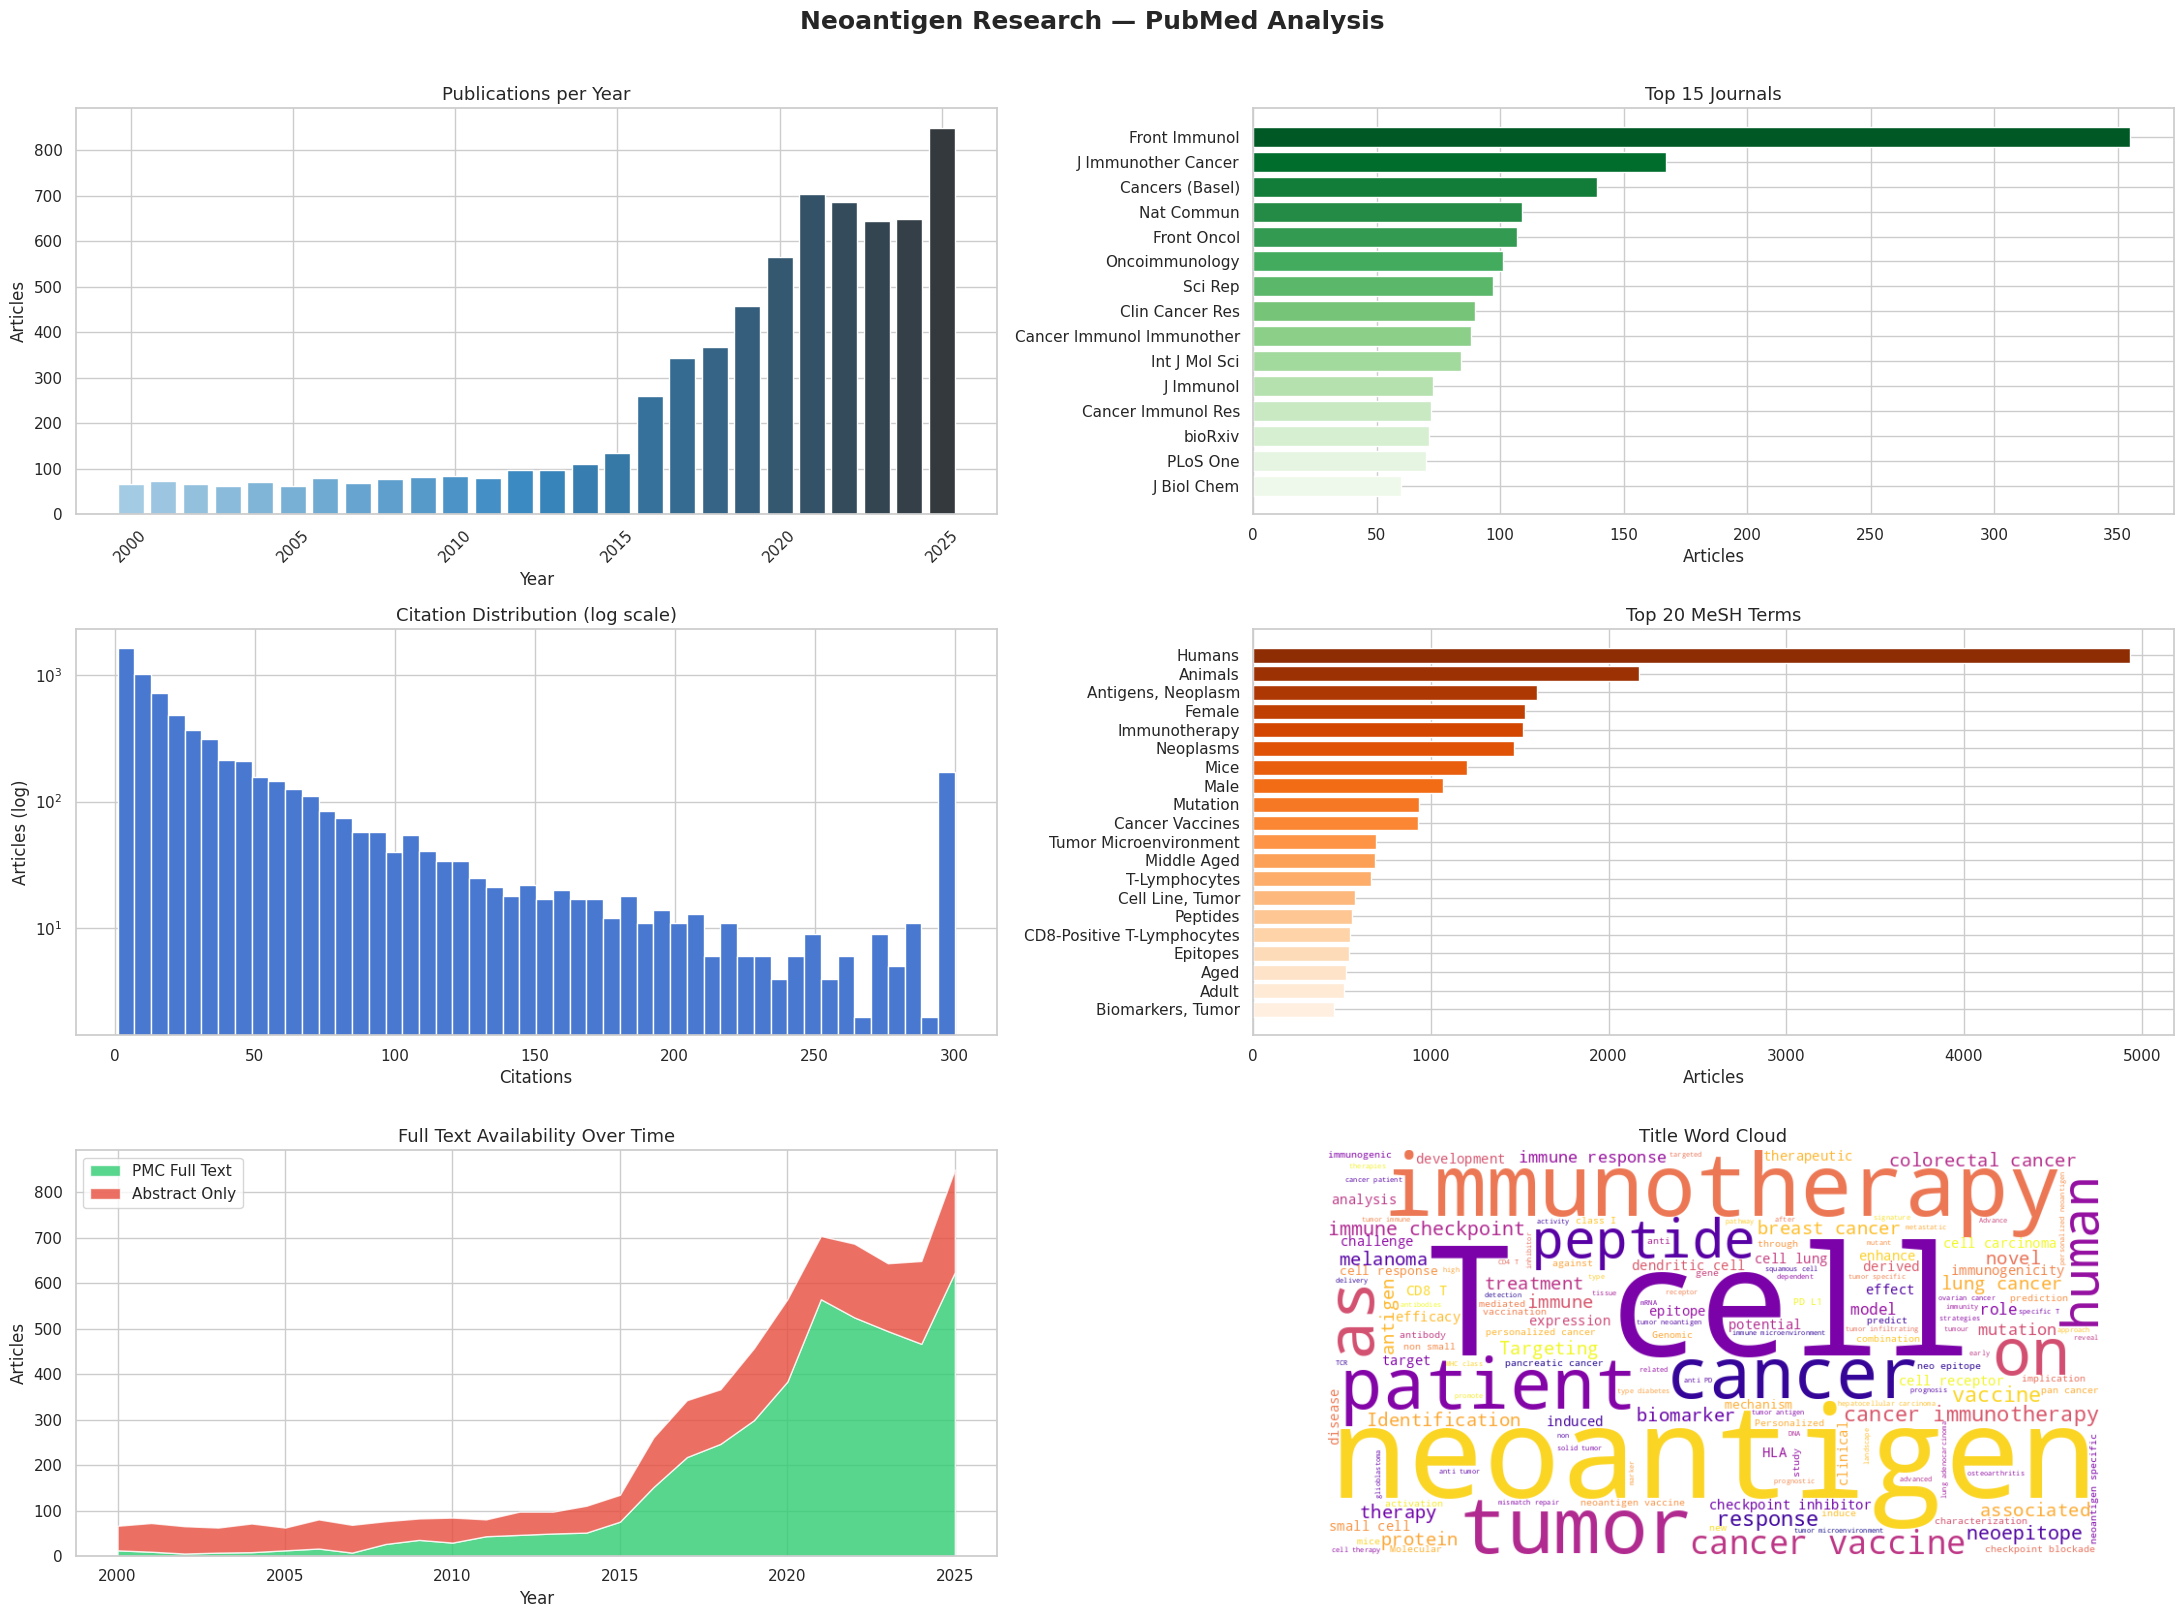

✅ Dashboard saved → neoantigen_dashboard.png


In [34]:
# ============================================================
# Cell 15: Visualisations
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")


def dashboard(conn: sqlite3.Connection):
    fig = plt.figure(figsize=(22, 16))
    fig.suptitle("Neoantigen Research — PubMed Analysis",
                 fontsize=18, fontweight="bold", y=1.01)

    axes = fig.subplot_mosaic("""
        AABB
        CCDD
        EEFF
    """)

    # ── A: Articles per year ──────────────────────────────
    ax = axes["A"]
    df1 = pd.read_sql_query("""
        SELECT pub_year, COUNT(*) cnt
        FROM articles WHERE pub_year BETWEEN 2000 AND 2025
        GROUP BY pub_year ORDER BY pub_year
    """, conn)
    if not df1.empty:
        ax.bar(df1["pub_year"], df1["cnt"],
               color=sns.color_palette("Blues_d", len(df1)),
               edgecolor="white")
        ax.set_title("Publications per Year", fontsize=13)
        ax.set_xlabel("Year"); ax.set_ylabel("Articles")
        ax.tick_params(axis="x", rotation=45)

    # ── B: Top 15 journals ────────────────────────────────
    ax = axes["B"]
    df2 = pd.read_sql_query("""
        SELECT journal_abbr, COUNT(*) cnt
        FROM articles WHERE journal_abbr != ''
        GROUP BY journal_abbr ORDER BY cnt DESC LIMIT 15
    """, conn)
    if not df2.empty:
        colors = sns.color_palette("Greens_r", len(df2))
        ax.barh(df2["journal_abbr"], df2["cnt"],
                color=colors, edgecolor="white")
        ax.invert_yaxis()
        ax.set_title("Top 15 Journals", fontsize=13)
        ax.set_xlabel("Articles")

    # ── C: Citation distribution ──────────────────────────
    ax = axes["C"]
    df3 = pd.read_sql_query(
        "SELECT cited_by FROM articles WHERE cited_by > 0", conn
    )
    if not df3.empty:
        ax.hist(df3["cited_by"].clip(upper=300),
                bins=50, color="#4878CF",
                edgecolor="white", log=True)
        ax.set_title("Citation Distribution (log scale)", fontsize=13)
        ax.set_xlabel("Citations"); ax.set_ylabel("Articles (log)")

    # ── D: Top 20 MeSH terms ─────────────────────────────
    ax = axes["D"]
    df4 = pd.read_sql_query("""
        SELECT descriptor, COUNT(*) cnt
        FROM mesh GROUP BY descriptor
        ORDER BY cnt DESC LIMIT 20
    """, conn)
    if not df4.empty:
        colors = sns.color_palette("Oranges_r", len(df4))
        ax.barh(df4["descriptor"], df4["cnt"],
                color=colors, edgecolor="white")
        ax.invert_yaxis()
        ax.set_title("Top 20 MeSH Terms", fontsize=13)
        ax.set_xlabel("Articles")

    # ── E: PMC availability over time ────────────────────
    ax = axes["E"]
    df5 = pd.read_sql_query("""
        SELECT pub_year,
               SUM(has_pmc_fulltext)           AS with_pmc,
               COUNT(*) - SUM(has_pmc_fulltext) AS without_pmc
        FROM articles WHERE pub_year BETWEEN 2000 AND 2025
        GROUP BY pub_year ORDER BY pub_year
    """, conn)
    if not df5.empty:
        ax.stackplot(df5["pub_year"],
                     df5["with_pmc"], df5["without_pmc"],
                     labels=["PMC Full Text","Abstract Only"],
                     colors=["#2ecc71","#e74c3c"],
                     alpha=0.8)
        ax.legend(loc="upper left")
        ax.set_title("Full Text Availability Over Time", fontsize=13)
        ax.set_xlabel("Year"); ax.set_ylabel("Articles")

    # ── F: Title word cloud ───────────────────────────────
    ax = axes["F"]
    titles = pd.read_sql_query(
        "SELECT title FROM articles", conn
    )["title"]
    text = " ".join(titles.dropna().tolist())
    stopwords = {"of","the","and","in","for","to","a","an",
                 "with","by","from","or","is","are","was","were",
                 "that","this","based","using","via","its","be"}
    if text.strip():
        wc = WordCloud(
            width=800, height=420,
            background_color="white",
            colormap="plasma",
            max_words=150,
            stopwords=stopwords,
            collocations=True,
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Title Word Cloud", fontsize=13)

    plt.tight_layout()
    out = "neoantigen_dashboard.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Dashboard saved → {out}")


dashboard(conn)

In [35]:
# ============================================================
# Cell 16: Top Papers Ranked by Citations
# ============================================================

def top_papers(conn, limit=25):
    df = pd.read_sql_query(f"""
        SELECT
            pmid, title, first_author,
            journal_abbr, pub_year,
            cited_by, pubmed_url, doi_url
        FROM articles
        WHERE cited_by > 0
        ORDER BY cited_by DESC
        LIMIT {limit}
    """, conn)
    return df

print(f"🏆 Top {25} most cited neoantigen papers:")
top = top_papers(conn, limit=25)
display(top)

🏆 Top 25 most cited neoantigen papers:


,pmid,title,first_author,journal_abbr,pub_year,cited_by,pubmed_url,doi_url
0,25765070,Cancer immunology. Mutational landscape determ...,"Rizvi, Naiyer A",Science,2015,6532,https://pubmed.ncbi.nlm.nih.gov/25765070/,https://doi.org/10.1126/science.aaa1348
1,28596308,Mismatch repair deficiency predicts response o...,"Le, Dung T",Science,2017,5222,https://pubmed.ncbi.nlm.nih.gov/28596308/,https://doi.org/10.1126/science.aan6733
2,29628290,The Immune Landscape of Cancer.,"Thorsson, Vesteinn",Immunity,2018,4308,https://pubmed.ncbi.nlm.nih.gov/29628290/,https://doi.org/10.1016/j.immuni.2018.03.023
3,29443960,TGFbeta attenuates tumour response to PD-L1 bl...,"Mariathasan, Sanjeev",Nature,2018,4105,https://pubmed.ncbi.nlm.nih.gov/29443960/,https://doi.org/10.1038/nature25501
4,28052254,Pan-cancer Immunogenomic Analyses Reveal Genot...,"Charoentong, Pornpimol",Cell Rep,2017,3789,https://pubmed.ncbi.nlm.nih.gov/28052254/,https://doi.org/10.1016/j.celrep.2016.12.019
5,25838375,Neoantigens in cancer immunotherapy.,"Schumacher, Ton N",Science,2015,3707,https://pubmed.ncbi.nlm.nih.gov/25838375/,https://doi.org/10.1126/science.aaa4971
6,25409260,Genetic basis for clinical response to CTLA-4 ...,"Snyder, Alexandra",N Engl J Med,2014,3458,https://pubmed.ncbi.nlm.nih.gov/25409260/,https://doi.org/10.1056/NEJMoa1406498
7,25594174,Molecular and genetic properties of tumors ass...,"Rooney, Michael S",Cell,2015,2916,https://pubmed.ncbi.nlm.nih.gov/25594174/,https://doi.org/10.1016/j.cell.2014.12.033
8,26940869,Clonal neoantigens elicit T cell immunoreactiv...,"McGranahan, Nicholas",Science,2016,2476,https://pubmed.ncbi.nlm.nih.gov/26940869/,https://doi.org/10.1126/science.aaf1490
9,26359337,Genomic correlates of response to CTLA-4 block...,"Van Allen, Eliezer M",Science,2015,2265,https://pubmed.ncbi.nlm.nih.gov/26359337/,https://doi.org/10.1126/science.aad0095


In [36]:
# ============================================================
# Cell 17: Co-authorship / Author Productivity
# ============================================================

def author_stats(conn, limit=20):
    df = pd.read_sql_query(f"""
        SELECT
            full_name,
            COUNT(DISTINCT pmid)            AS papers,
            SUM(CASE WHEN is_first=1 THEN 1 ELSE 0 END) AS first_auth,
            SUM(CASE WHEN is_last=1  THEN 1 ELSE 0 END) AS last_auth
        FROM authors
        WHERE full_name IS NOT NULL AND full_name != ''
        GROUP BY full_name
        ORDER BY papers DESC
        LIMIT {limit}
    """, conn)
    return df

print("👤 Most prolific authors:")
display(author_stats(conn, limit=20))

👤 Most prolific authors:


,full_name,papers,first_auth,last_auth
0,"Karsdal, Morten A",55,1,13
1,"Rosenberg, Steven A",52,0,32
2,"Wu, Catherine J",50,0,20
3,"Robbins, Paul F",42,1,6
4,"Zhang, Jian",35,3,13
5,"Nakamura, Yusuke",35,0,13
6,"Gartner, Jared J",35,1,0
7,"Chan, Timothy A",35,0,16
8,"Coukos, George",34,0,5
9,"Sahin, Ugur",33,2,13


In [37]:
# ============================================================
# Cell 18: Funding Agency Analysis
# ============================================================

def funding_stats(conn, limit=15):
    df = pd.read_sql_query(f"""
        SELECT
            agency,
            COUNT(DISTINCT pmid) AS papers,
            COUNT(*)             AS grants
        FROM grants
        WHERE agency IS NOT NULL AND agency != ''
        GROUP BY agency
        ORDER BY papers DESC
        LIMIT {limit}
    """, conn)
    return df

print("💰 Top funding agencies:")
display(funding_stats(conn, limit=15))

💰 Top funding agencies:


,agency,papers,grants
0,NCI NIH HHS,1029,3007
1,NIAID NIH HHS,291,572
2,NIGMS NIH HHS,284,394
3,NHLBI NIH HHS,200,443
4,NIDDK NIH HHS,156,317
5,NIH HHS,132,214
6,NIAMS NIH HHS,118,258
7,NCATS NIH HHS,112,144
8,NINDS NIH HHS,106,203
9,Cancer Research UK,82,262


In [38]:
# ============================================================
# Cell 19: Close
# ============================================================

conn.close()
print(f"✅ All done — DB saved to: {CONFIG['db_path']}")

✅ All done — DB saved to: neoantigen_pubmed.db
